# What Makes a World Cup Champion?
### A Machine Learning Analysis of FIFA World Cup 1974–2022
**Research Questions:**
1. *Can we identify the statistical profile that separates World Cup champions from every other team?*
2. *Which match-level features are most predictive of champion performance?*

**Dataset:**
- **Source:** [Kaggle – FIFA World Cup](https://www.kaggle.com/datasets/samyakrajbayar/fifa-world-cup)
- **Coverage:** 43 curated matches across 13 World Cups (1974–2022)
- **Features:** Goals, xG, possession, shots, corners, fouls, cards, attendance

**Project Pipeline:**
1. Data Loading & Preparation
2. Feature Engineering
3. Exploratory Data Analysis (EDA)
4. Model Training & Evaluation
5. Insights & Conclusions

## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import LeaveOneOut, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (    classification_report, confusion_matrix, roc_auc_score,    accuracy_score, f1_score, precision_score, recall_score)


## 1. Data Loading & Preparation
**Goal:** Transform the raw match-level dataset into a team-match-level dataset and label which teams are World Cup champions.

- **Input:** `data/fifa_world_cup_enhanced_1974_2022.csv` (43 matches, one row per match)
- **Output:** 86 rows (one row per team per match)

### 1.1 Load the Raw Data

In [3]:
df = pd.read_csv('../data/fifa_world_cup_enhanced_1974_2022.csv')

print(f"Loaded raw data: {df.shape[0]} matches, {df.shape[1]} columns")
print(f"Years covered: {df['year'].min()} - {df['year'].max()}")
df.head()

Loaded raw data: 43 matches, 38 columns
Years covered: 1974 - 2022


,match_id,year,date,stage,home_team,away_team,home_goals,away_goals,winner,goal_difference,...,venue,city,referee,home_goals_detail,away_goals_detail,penalty_shootout,penalty_home,penalty_away,tournament_format,host_nations
0,WC-1974-001,1974,1974-06-13,Group 1,Brazil,Yugoslavia,0,0,Draw,0,...,Waldstadion,Frankfurt,Károly Palotai (Hungary),NaN,Jovan Aćimović (60'),No,NaN,NaN,16,West Germany
1,WC-1974-038,1974,1974-07-07,Final,West Germany,Netherlands,2,1,West Germany,1,...,Olympiastadion,Munich,John Taylor (England),"Paul Breitner (25' pen), Gerd Müller (43')",Johan Neeskens (2' pen),No,NaN,NaN,16,West Germany
2,WC-1974-008,1974,1974-06-18,Group 2,Yugoslavia,Zaire,9,0,Yugoslavia,9,...,Parkstadion,Gelsenkirchen,Omar Delgado (Colombia),"Dušan Bajević (8', 30', 81'), Dragan Džajić (1...",NaN,No,NaN,NaN,16,West Germany
3,WC-1974-012,1974,1974-06-22,Group A,Netherlands,Brazil,2,0,Netherlands,2,...,Westfalenstadion,Dortmund,Kurt Tschenscher (West Germany),"Johan Neeskens (50'), Johan Cruyff (65')",NaN,No,NaN,NaN,16,West Germany
4,WC-1978-038,1978,1978-06-25,Final,Argentina,Netherlands,3,1,Argentina,2,...,Estadio Monumental,Buenos Aires,Sergio Gonella (Italy),"Mario Kempes (38', 105'), Daniel Bertoni (115')",Dirk Nanninga (82'),Yes (AET),NaN,NaN,16,Argentina


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 38 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   match_id             43 non-null     str    
 1   year                 43 non-null     int64  
 2   date                 43 non-null     str    
 3   stage                43 non-null     str    
 4   home_team            43 non-null     str    
 5   away_team            43 non-null     str    
 6   home_goals           43 non-null     int64  
 7   away_goals           43 non-null     int64  
 8   winner               43 non-null     str    
 9   goal_difference      43 non-null     int64  
 10  total_goals          43 non-null     int64  
 11  home_xg              43 non-null     float64
 12  away_xg              43 non-null     float64
 13  possession_home      43 non-null     int64  
 14  possession_away      43 non-null     int64  
 15  shots_home           43 non-null     int64  
 16  sho

### 1.2 Reshape: One Row per Team per Match

Each row has both teams' stats mixed together (home\_goals, away\_goals, etc). We split each match into **two rows**, one from each team's perspective.

Example: `Brazil 2 - 0 Germany` becomes:
- Row 1: Brazil → goals=2, goals\_conceded=0, possession=52...
- Row 2: Germany → goals=0, goals\_conceded=2, possession=48...

In [5]:
rows = []

for _, match in df.iterrows():

    # --- Home team's row ---
    rows.append({
        'match_id':             match['match_id'],
        'year':                 match['year'],
        'date':                 match['date'],
        'stage':                match['stage'],
        'team':                 match['home_team'],
        'opponent':             match['away_team'],
        'is_home':              1,
        'goals':                match['home_goals'],
        'goals_conceded':       match['away_goals'],
        'xg':                   match['home_xg'],
        'xg_against':           match['away_xg'],
        'possession':           match['possession_home'],
        'shots':                match['shots_home'],
        'shots_on_target':      match['shots_ontarget_home'],
        'corners':              match['corners_home'],
        'fouls':                match['fouls_home'],
        'yellow_cards':         match['yellow_cards_home'],
        'red_cards':            match['red_cards_home'],
        'opp_shots':            match['shots_away'],
        'opp_shots_on_target':  match['shots_ontarget_away'],
        'won_match':            1 if match['winner'] == match['home_team'] else 0,
        'attendance':           match['attendance'],
    })

    # --- Away team's row (everything flipped) ---
    rows.append({
        'match_id':             match['match_id'],
        'year':                 match['year'],
        'date':                 match['date'],
        'stage':                match['stage'],
        'team':                 match['away_team'],
        'opponent':             match['home_team'],
        'is_home':              0,
        'goals':                match['away_goals'],
        'goals_conceded':       match['home_goals'],
        'xg':                   match['away_xg'],
        'xg_against':           match['home_xg'],
        'possession':           match['possession_away'],
        'shots':                match['shots_away'],
        'shots_on_target':      match['shots_ontarget_away'],
        'corners':              match['corners_away'],
        'fouls':                match['fouls_away'],
        'yellow_cards':         match['yellow_cards_away'],
        'red_cards':            match['red_cards_away'],
        'opp_shots':            match['shots_home'],
        'opp_shots_on_target':  match['shots_ontarget_home'],
        'won_match':            1 if match['winner'] == match['away_team'] else 0,
        'attendance':           match['attendance'],
    })

team_df = pd.DataFrame(rows)
print(f"Reshaped: {df.shape[0]} matches → {team_df.shape[0]} team-match rows")
team_df.head(6)

Reshaped: 43 matches → 86 team-match rows


,match_id,year,date,stage,team,opponent,is_home,goals,goals_conceded,xg,...,shots,shots_on_target,corners,fouls,yellow_cards,red_cards,opp_shots,opp_shots_on_target,won_match,attendance
0,WC-1974-001,1974,1974-06-13,Group 1,Brazil,Yugoslavia,1,0,0,1.8,...,14,5,6,12,1,0,9,3,0,62000
1,WC-1974-001,1974,1974-06-13,Group 1,Yugoslavia,Brazil,0,0,0,1.2,...,9,3,4,15,2,0,14,5,0,62000
2,WC-1974-038,1974,1974-07-07,Final,West Germany,Netherlands,1,2,1,1.5,...,11,6,5,18,3,0,17,7,1,80000
3,WC-1974-038,1974,1974-07-07,Final,Netherlands,West Germany,0,1,2,2.1,...,17,7,8,14,2,0,11,6,0,80000
4,WC-1974-008,1974,1974-06-18,Group 2,Yugoslavia,Zaire,1,9,0,5.1,...,28,17,14,9,0,0,2,0,1,31700
5,WC-1974-008,1974,1974-06-18,Group 2,Zaire,Yugoslavia,0,0,9,0.1,...,2,0,0,13,2,0,28,17,0,31700


### 1.3 Label the Champions

In [6]:
# Find who won the final each year = that year's World Cup champion
finals = df[df['stage'] == 'Final']
tournament_winners = {}

for _, final in finals.iterrows():
    tournament_winners[final['year']] = final['winner']

print("Tournament Winners:")
for year, winner in sorted(tournament_winners.items()):
    print(f"  {year}: {winner}")

Tournament Winners:
  1974: West Germany
  1978: Argentina
  1982: Italy
  1986: Argentina
  1990: West Germany
  1994: Brazil
  1998: France
  2002: Brazil
  2006: Italy
  2010: Spain
  2014: Germany
  2018: France
  2022: Argentina


In [7]:
# Add champion label: 1 if team won the World Cup that year, 0 otherwise
team_df['is_champion'] = team_df.apply(
    lambda row: 1 if tournament_winners.get(row['year']) == row['team'] else 0,
    axis=1
)

# Class balance
champ_count = team_df['is_champion'].sum()
non_champ_count = (team_df['is_champion'] == 0).sum()
print(f"Champion rows:     {champ_count} ({champ_count/len(team_df)*100:.1f}%)")
print(f"Non-champion rows: {non_champ_count} ({non_champ_count/len(team_df)*100:.1f}%)")

Champion rows:     24 (27.9%)
Non-champion rows: 62 (72.1%)


### 1.4 Validation

In [8]:
# Verify champion labels
champ_rows = team_df[team_df['is_champion'] == 1]
for year in sorted(champ_rows['year'].unique()):
    subset = champ_rows[champ_rows['year'] == year]
    team = subset['team'].iloc[0]
    matches = len(subset)
    opponents = ', '.join(subset['opponent'].tolist())
    print(f"  {year} {team} ({matches} matches): vs {opponents}")

  1974 West Germany (1 matches): vs Netherlands
  1978 Argentina (2 matches): vs Netherlands, Peru
  1982 Italy (1 matches): vs West Germany
  1986 Argentina (2 matches): vs West Germany, England
  1990 West Germany (2 matches): vs Argentina, Italy
  1994 Brazil (2 matches): vs Italy, USA
  1998 France (1 matches): vs Brazil
  2002 Brazil (3 matches): vs Germany, England, Turkey
  2006 Italy (1 matches): vs France
  2010 Spain (2 matches): vs Netherlands, Switzerland
  2014 Germany (2 matches): vs Argentina, Brazil
  2018 France (2 matches): vs Croatia, Belgium
  2022 Argentina (3 matches): vs France, Croatia, Netherlands


In [9]:
# Sanity check: Argentina 2022
sample = team_df[(team_df['team'] == 'Argentina') & (team_df['year'] == 2022)]
sample[['team', 'opponent', 'stage', 'goals', 'goals_conceded',
        'possession', 'xg', 'won_match', 'is_champion']]

,team,opponent,stage,goals,goals_conceded,possession,xg,won_match,is_champion
68,Argentina,France,Final,3,3,45,2.1,1,1
70,Argentina,Croatia,Semi-final,3,0,56,2.4,1,1
85,Argentina,Netherlands,Quarter-final,2,2,53,1.9,1,1


## 2. Feature Engineering

**Goal:** Create meaningful derived features from the raw stats that better capture what makes a team perform like a champion.

### 2.1 Attacking Features

In [10]:
# Shot Conversion Rate: what % of shots become goals?
# Champions are clinical — they don't just shoot, they score.
team_df['shot_conversion'] = (team_df['goals'] / team_df['shots'] * 100).round(2)

# xG Overperformance: goals scored minus expected goals
# Positive = scoring more than expected (clutch/clinical)
# Negative = wasteful in front of goal
team_df['xg_overperformance'] = (team_df['goals'] - team_df['xg']).round(2)

# Shots on Target Rate: what % of shots hit the target?
# Shows quality of chances, not just volume
team_df['shot_accuracy'] = (team_df['shots_on_target'] / team_df['shots'] * 100).round(2)

print("Attacking Features Created:")
print(f"  shot_conversion:    goals / shots * 100")
print(f"  xg_overperformance: goals - xG")
print(f"  shot_accuracy:      shots_on_target / shots * 100")

Attacking Features Created:
  shot_conversion:    goals / shots * 100
  xg_overperformance: goals - xG
  shot_accuracy:      shots_on_target / shots * 100


### 2.2 Defensive Features

In [11]:
# Defensive Save Rate: what % of opponent shots did NOT go in?
# Higher = harder to score against
team_df['defensive_save_rate'] = ((1 - team_df['goals_conceded'] / team_df['opp_shots']) * 100).round(2)

# xG Against Overperformance: expected goals against minus actual goals conceded
# Positive = conceding LESS than expected (strong defense/keeper)
team_df['defensive_xg_overperf'] = (team_df['xg_against'] - team_df['goals_conceded']).round(2)

# Shots Allowed per Foul: how many opponent shots per foul committed
# Lower could mean smart tactical fouling
team_df['shots_allowed_per_foul'] = (team_df['opp_shots'] / team_df['fouls']).round(2)

print("Defensive Features Created:")
print(f"  defensive_save_rate:    (1 - goals_conceded / opp_shots) * 100")
print(f"  defensive_xg_overperf:  xG_against - goals_conceded")
print(f"  shots_allowed_per_foul: opp_shots / fouls")

Defensive Features Created:
  defensive_save_rate:    (1 - goals_conceded / opp_shots) * 100
  defensive_xg_overperf:  xG_against - goals_conceded
  shots_allowed_per_foul: opp_shots / fouls


### 2.3 Dominance & Discipline Features

In [12]:
# Goal Difference: simple but powerful
team_df['goal_difference'] = team_df['goals'] - team_df['goals_conceded']

# Shot Dominance: ratio of your shots vs opponent shots
# >1 means you're outshooting them
team_df['shot_dominance'] = (team_df['shots'] / team_df['opp_shots']).round(2)

# Corner Ratio: corners won vs opponent
# Shows how much pressure you're applying
team_df['corner_dominance'] = (team_df['corners'] / (team_df['corners'] + team_df['opp_shots_on_target'])).round(2)

# Possession Effectiveness: goals scored per % of possession
# Are you doing something useful with the ball?
team_df['possession_effectiveness'] = (team_df['goals'] / team_df['possession'] * 100).round(2)

# Discipline Score: weighted card penalty
# Yellow = 1 point, Red = 3 points (harsher punishment)
team_df['discipline_score'] = team_df['yellow_cards'] + (team_df['red_cards'] * 3)

# Encode knockout stages as a numeric "pressure level"
# Higher number = higher stakes match
stage_map = {
    'Group 1': 1, 'Group 2': 1, 'Group 3': 1,
    'Group A': 1, 'Group B': 1, 'Group C': 1,
    'Group D': 1, 'Group E': 1, 'Group F': 1,
    'Group H': 1,
    'Round of 16': 2,
    'Quarter-final': 3,
    'Semi-final': 4,
    'Final': 5,
}
team_df['stage_level'] = team_df['stage'].map(stage_map)

print(f"Total features: {team_df.shape[1]} columns ({team_df.shape[1] - 23} engineered)")

Total features: 35 columns (12 engineered)


### 2.4 Feature Comparison: Champions vs Non-Champions

In [13]:
champ = team_df[team_df['is_champion'] == 1]
non_champ = team_df[team_df['is_champion'] == 0]

new_features = [
    'shot_conversion', 'xg_overperformance', 'shot_accuracy',
    'defensive_save_rate', 'defensive_xg_overperf', 'goal_difference',
    'shot_dominance', 'possession_effectiveness', 'discipline_score'
]

print(f'{"Feature":<30} {"Champion":>10} {"Other":>10} {"Diff":>10}')
print("-" * 62)

for feat in new_features:
    c_avg = champ[feat].mean()
    nc_avg = non_champ[feat].mean()
    diff = c_avg - nc_avg
    sign = "+" if diff > 0 else ""
    print(f"{feat:<30} {c_avg:>10.2f} {nc_avg:>10.2f} {sign}{diff:>9.2f}")

Feature                          Champion      Other       Diff
--------------------------------------------------------------
shot_conversion                     15.12       9.67 +     5.45
xg_overperformance                   0.19      -0.13 +     0.32
shot_accuracy                       47.46      37.26 +    10.20
defensive_save_rate                 93.54      86.98 +     6.56
defensive_xg_overperf                0.45      -0.11 +     0.56
goal_difference                      1.46      -0.56 +     2.02
shot_dominance                       1.75       1.30 +     0.45
possession_effectiveness             4.23       2.60 +     1.63
discipline_score                     2.67       2.85     -0.19


## 3. Exploratory Data Analysis (EDA)

### 3.1 Bar Comparison: Champion vs Non-Champion Averages

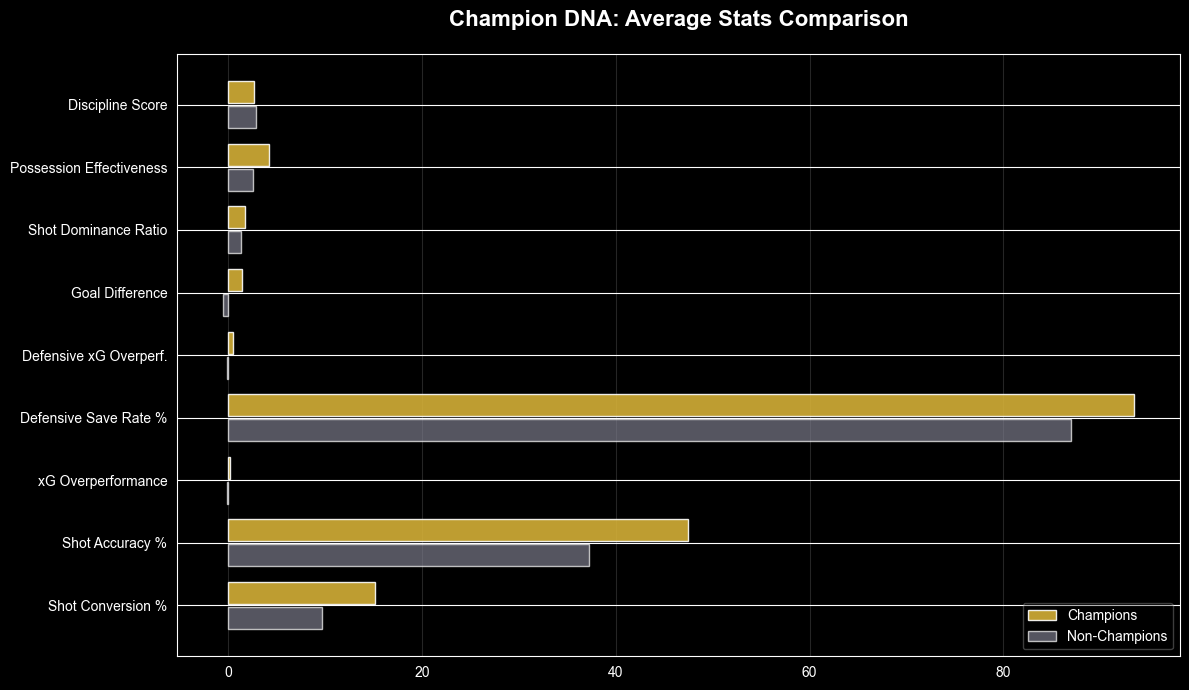

In [14]:
features = [
    ('shot_conversion', 'Shot Conversion %'),
    ('shot_accuracy', 'Shot Accuracy %'),
    ('xg_overperformance', 'xG Overperformance'),
    ('defensive_save_rate', 'Defensive Save Rate %'),
    ('defensive_xg_overperf', 'Defensive xG Overperf.'),
    ('goal_difference', 'Goal Difference'),
    ('shot_dominance', 'Shot Dominance Ratio'),
    ('possession_effectiveness', 'Possession Effectiveness'),
    ('discipline_score', 'Discipline Score'),
]

fig, ax = plt.subplots(figsize=(12, 7))

y_pos = np.arange(len(features))
champ_vals = [champ[f[0]].mean() for f in features]
non_champ_vals = [non_champ[f[0]].mean() for f in features]

bars1 = ax.barh(y_pos + 0.2, champ_vals, 0.35, color='#D4AF37', label='Champions', alpha=0.9)
bars2 = ax.barh(y_pos - 0.2, non_champ_vals, 0.35, color='#7A7A8A', label='Non-Champions', alpha=0.7)

ax.set_yticks(y_pos)
ax.set_yticklabels([f[1] for f in features])
ax.set_title('Champion DNA: Average Stats Comparison', fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='lower right', framealpha=0.3)
ax.grid(axis='x', alpha=0.15)

plt.tight_layout()
plt.show()

### 3.2 Radar Chart: Champion Profile

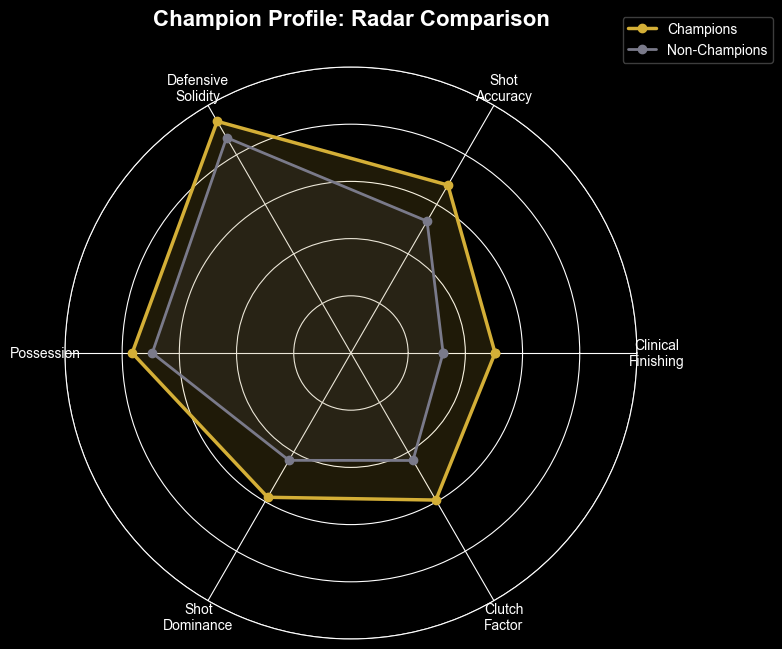

In [15]:
radar_features = [
    ('shot_conversion', 'Clinical\nFinishing', 30),
    ('shot_accuracy', 'Shot\nAccuracy', 70),
    ('defensive_save_rate', 'Defensive\nSolidity', 100),
    ('possession', 'Possession', 70),
    ('shot_dominance', 'Shot\nDominance', 3),
    ('xg_overperformance', 'Clutch\nFactor', 2),
]

# Normalize to 0-1 scale for radar
champ_radar = []
non_champ_radar = []
for feat, label, max_val in radar_features:
    c_val = champ[feat].mean() / max_val
    nc_val = non_champ[feat].mean() / max_val
    # Handle negative values (like xg_overperformance)
    c_val = max(0, min(1, (c_val + 0.5) if max_val <= 2 else c_val))
    nc_val = max(0, min(1, (nc_val + 0.5) if max_val <= 2 else nc_val))
    champ_radar.append(c_val)
    non_champ_radar.append(nc_val)

angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]
champ_radar += champ_radar[:1]
non_champ_radar += non_champ_radar[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.plot(angles, champ_radar, 'o-', color='#D4AF37', linewidth=2.5, label='Champions')
ax.fill(angles, champ_radar, color='#D4AF37', alpha=0.15)
ax.plot(angles, non_champ_radar, 'o-', color='#7A7A8A', linewidth=2, label='Non-Champions')
ax.fill(angles, non_champ_radar, color='#7A7A8A', alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([f[1] for f in radar_features], size=10)
ax.set_ylim(0, 1)
ax.set_yticklabels([])
ax.set_title('Champion Profile: Radar Comparison', fontsize=16, fontweight='bold', pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1), framealpha=0.3)

plt.tight_layout()
plt.show()

### 3.3 xG vs Actual Goals: Do Champions Overperform?

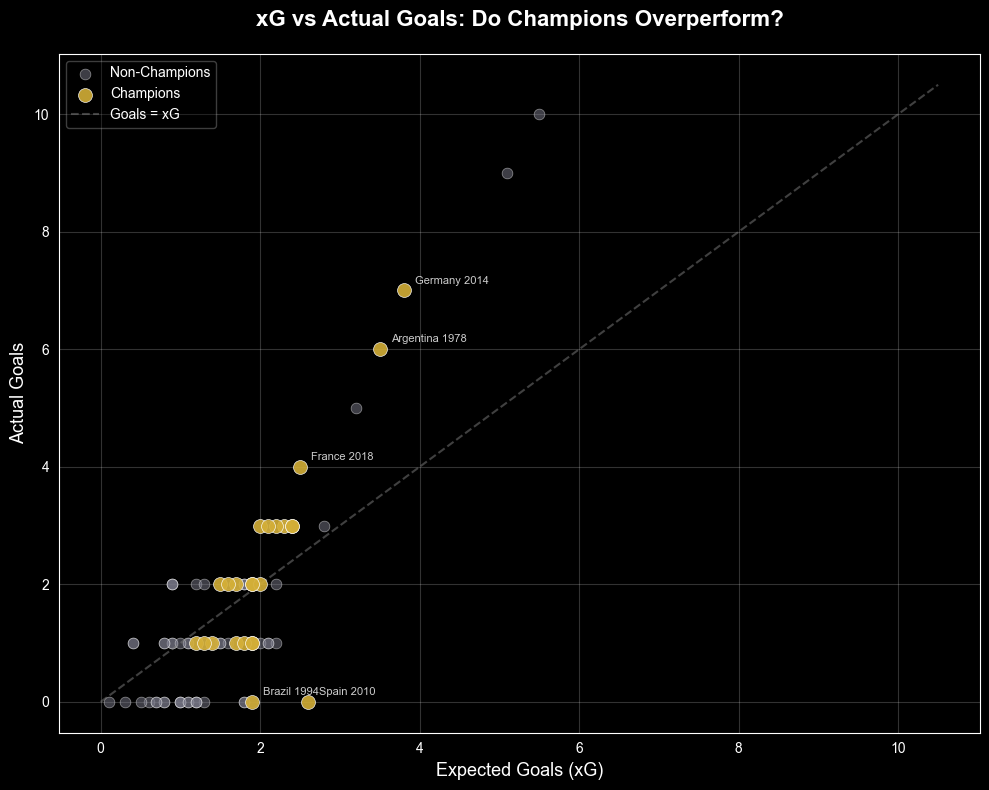

In [16]:
fig, ax = plt.subplots(figsize=(10, 8))

# Non-champions
ax.scatter(non_champ['xg'], non_champ['goals'], c='#7A7A8A', alpha=0.5, s=60,
           label='Non-Champions', edgecolors='white', linewidth=0.5)
# Champions
ax.scatter(champ['xg'], champ['goals'], c='#D4AF37', alpha=0.9, s=100,
           label='Champions', edgecolors='white', linewidth=0.5, zorder=5)

# Perfect line (goals = xG)
max_val = max(team_df['xg'].max(), team_df['goals'].max()) + 0.5
ax.plot([0, max_val], [0, max_val], '--', color='gray', alpha=0.5, label='Goals = xG')

# Annotate some champion data points
for _, row in champ.iterrows():
    if abs(row['goals'] - row['xg']) > 1.5 or row['goals'] >= 4:
        ax.annotate(f"{row['team']} {row['year']}", (row['xg'], row['goals']),
                    fontsize=8, alpha=0.8,
                    xytext=(8, 5), textcoords='offset points')

ax.set_xlabel('Expected Goals (xG)', fontsize=13)
ax.set_ylabel('Actual Goals', fontsize=13)
ax.set_title('xG vs Actual Goals: Do Champions Overperform?', fontsize=16, fontweight='bold', pad=20)
ax.legend(framealpha=0.3)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### 3.4 Key Feature Distributions

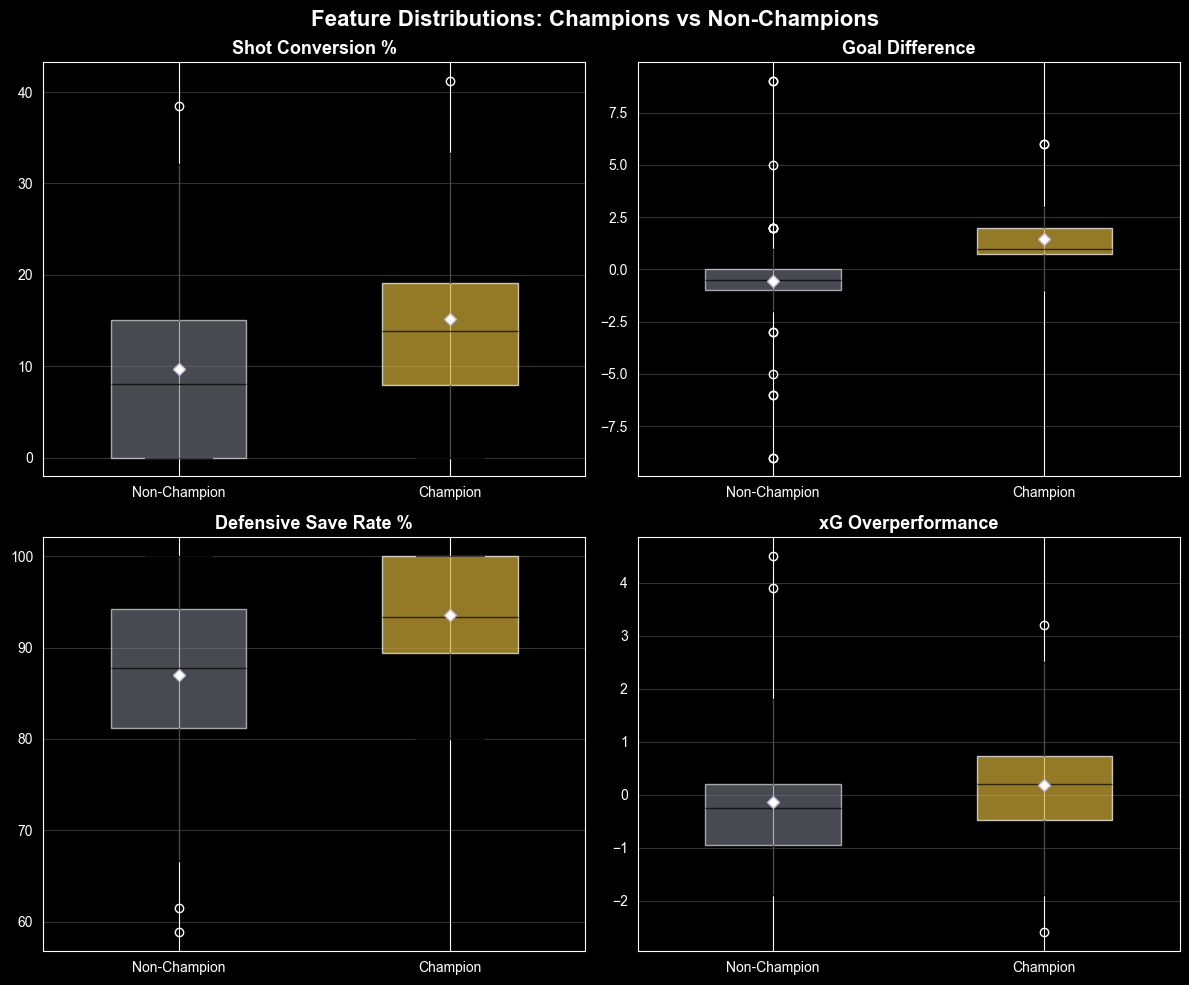

In [17]:
box_features = [
    ('shot_conversion', 'Shot Conversion %'),
    ('goal_difference', 'Goal Difference'),
    ('defensive_save_rate', 'Defensive Save Rate %'),
    ('xg_overperformance', 'xG Overperformance'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (feat, label) in enumerate(box_features):
    ax = axes[i]
    data = [non_champ[feat].values, champ[feat].values]
    bp = ax.boxplot(data, tick_labels=['Non-Champion', 'Champion'], patch_artist=True,
                    widths=0.5, showmeans=True,
                    meanprops=dict(marker='D', markerfacecolor='white', markersize=6))

    bp['boxes'][0].set_facecolor('#7A7A8A')
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('#D4AF37')
    bp['boxes'][1].set_alpha(0.7)

    for element in ['whiskers', 'caps', 'medians']:
        for line in bp[element]:
            line.set_color('black')
            line.set_alpha(0.7)

    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.2)

fig.suptitle('Feature Distributions: Champions vs Non-Champions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.5 Champion Evolution Timeline

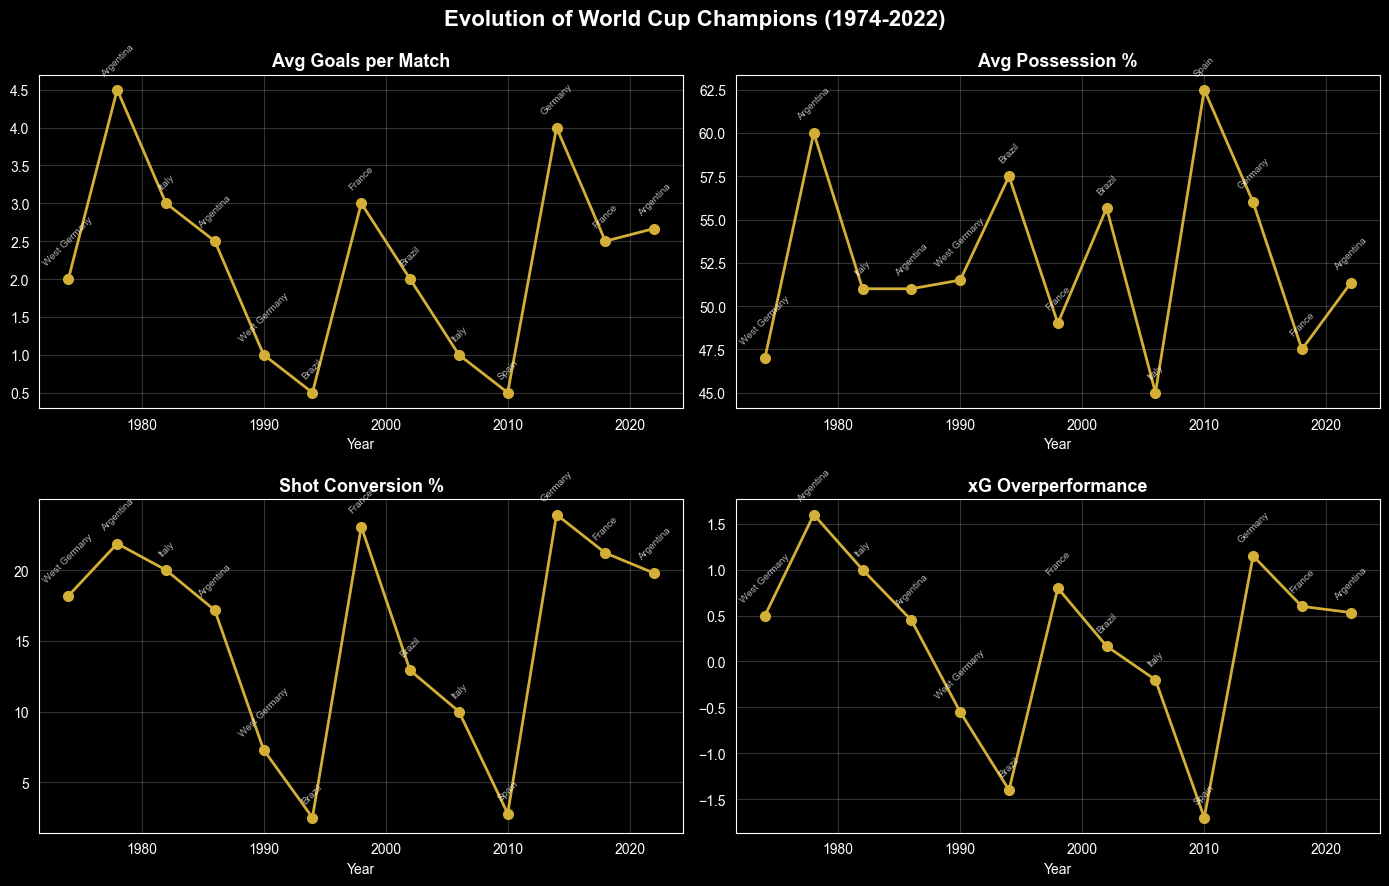

In [18]:
timeline = champ.groupby('year').agg({
    'goals': 'mean',
    'possession': 'mean',
    'shot_conversion': 'mean',
    'xg_overperformance': 'mean',
    'team': 'first',
}).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

metrics = [
    ('goals', 'Avg Goals per Match'),
    ('possession', 'Avg Possession %'),
    ('shot_conversion', 'Shot Conversion %'),
    ('xg_overperformance', 'xG Overperformance'),
]

for i, (col, title) in enumerate(metrics):
    ax = axes[i]
    ax.plot(timeline['year'], timeline[col], 'o-', color='#D4AF37', linewidth=2, markersize=7)

    # Label each point with the team name
    for _, row in timeline.iterrows():
        ax.annotate(row['team'], (row['year'], row[col]),
                    fontsize=7, alpha=0.7,
                    xytext=(0, 10), textcoords='offset points',
                    ha='center', rotation=45)

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(alpha=0.2)
    ax.set_xlabel('Year')

fig.suptitle('Evolution of World Cup Champions (1974-2022)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Key EDA Findings

- Champions score **15.1%** of their shots vs 9.7%
- Champions save **93.5%** of opponent shots vs 87.0%
- Champions overperform xG by **+0.19**, others underperform by -0.13
- Champions avg goal diff: **+1.5** vs -0.6

## 4. Model Training & Evaluation

With only 86 samples, we use simple but effective models and validate with both **Stratified 5-Fold** and **Leave-One-Out** cross-validation.

### 4.1 Feature Selection & Scaling

In [19]:
# Features we engineered in Step 2 + key raw stats
FEATURES = [
    # Raw stats
    'possession', 'shots', 'shots_on_target', 'corners',
    'xg', 'xg_against', 'opp_shots', 'opp_shots_on_target',
    # Engineered features
    'shot_conversion', 'xg_overperformance', 'shot_accuracy',
    'defensive_save_rate', 'defensive_xg_overperf',
    'goal_difference', 'shot_dominance', 'possession_effectiveness',
    'discipline_score', 'stage_level',
]

X = team_df[FEATURES]
y = team_df['is_champion']

# Important: models like Logistic Regression need scaled features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=FEATURES)

print(f"Features: {len(FEATURES)}")
print(f"Samples:  {len(X)} ({y.sum()} champion, {(y==0).sum()} non-champion)")

Features: 18
Samples:  86 (24 champion, 62 non-champion)


### 4.2 Model Definitions

In [20]:
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',  # Handle imbalanced classes
        max_iter=1000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        max_depth=4,            # Keep it shallow — small dataset
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        random_state=42
    ),
}

### 4.3 Stratified 5-Fold Cross-Validation

In [21]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'{"Model":<25} {"Accuracy":>10} {"F1":>10} {"Precision":>10} {"Recall":>10} {"ROC-AUC":>10}')
print("-" * 77)

results = {}

for name, model in models.items():
    y_pred = cross_val_predict(model, X_scaled, y, cv=skf)
    y_prob = cross_val_predict(model, X_scaled, y, cv=skf, method='predict_proba')[:, 1]

    acc = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    prec = precision_score(y, y_pred)
    rec = recall_score(y, y_pred)
    auc = roc_auc_score(y, y_prob)

    results[name] = {'accuracy': acc, 'f1': f1, 'precision': prec, 'recall': rec, 'auc': auc}
    print(f"{name:<25} {acc:>10.3f} {f1:>10.3f} {prec:>10.3f} {rec:>10.3f} {auc:>10.3f}")

Model                       Accuracy         F1  Precision     Recall    ROC-AUC
-----------------------------------------------------------------------------
Logistic Regression            0.779      0.655      0.581      0.750      0.858
Random Forest                  0.779      0.578      0.619      0.542      0.805
Gradient Boosting              0.744      0.522      0.545      0.500      0.792


### 4.4 Leave-One-Out Cross-Validation

In [22]:
loo = LeaveOneOut()
loo_results = {}

print(f'{"Model":<25} {"Accuracy":>10} {"F1":>10} {"Precision":>10} {"Recall":>10} {"ROC-AUC":>10}')
print("-" * 77)

for name, model in models.items():
    y_pred = cross_val_predict(model, X_scaled, y, cv=loo)
    y_prob = cross_val_predict(model, X_scaled, y, cv=loo, method='predict_proba')[:, 1]

    acc = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    prec = precision_score(y, y_pred)
    rec = recall_score(y, y_pred)
    auc = roc_auc_score(y, y_prob)

    loo_results[name] = {'accuracy': acc, 'f1': f1, 'precision': prec, 'recall': rec, 'auc': auc}
    print(f"{name:<25} {acc:>10.3f} {f1:>10.3f} {prec:>10.3f} {rec:>10.3f} {auc:>10.3f}")

Model                       Accuracy         F1  Precision     Recall    ROC-AUC
-----------------------------------------------------------------------------
Logistic Regression            0.779      0.655      0.581      0.750      0.847
Random Forest                  0.779      0.596      0.609      0.583      0.807
Gradient Boosting              0.767      0.524      0.611      0.458      0.750


### 4.5 Feature Importance

In [23]:
# Train on full data for feature importance
rf = RandomForestClassifier(
    n_estimators=100, class_weight='balanced',
    max_depth=4, random_state=42
)
rf.fit(X_scaled, y)

importances = pd.DataFrame({
    'feature': FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

for _, row in importances.iterrows():
    bar = '█' * int(row['importance'] * 100)
    print(f"  {row['feature']:<28} {row['importance']:.4f}  {bar}")

  shot_accuracy                0.1329  █████████████
  goal_difference              0.1162  ███████████
  xg                           0.1117  ███████████
  stage_level                  0.0823  ████████
  defensive_xg_overperf        0.0735  ███████
  defensive_save_rate          0.0679  ██████
  possession                   0.0650  ██████
  shots_on_target              0.0552  █████
  shots                        0.0422  ████
  opp_shots_on_target          0.0413  ████
  xg_against                   0.0386  ███
  possession_effectiveness     0.0313  ███
  shot_dominance               0.0306  ███
  xg_overperformance           0.0259  ██
  discipline_score             0.0235  ██
  corners                      0.0232  ██
  opp_shots                    0.0214  ██
  shot_conversion              0.0174  █


### 4.6 Logistic Regression Coefficients

In [24]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_scaled, y)

coefs = pd.DataFrame({
    'feature': FEATURES,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', ascending=False)

print("(Positive = more likely champion, Negative = less likely)\n")
for _, row in coefs.iterrows():
    sign = '+' if row['coefficient'] > 0 else ''
    print(f"  {row['feature']:<28} {sign}{row['coefficient']:.4f}")

(Positive = more likely champion, Negative = less likely)

  shot_conversion              +1.4423
  stage_level                  +1.1353
  corners                      +1.0513
  shot_accuracy                +0.7275
  defensive_save_rate          +0.5568
  defensive_xg_overperf        +0.4797
  possession                   +0.2938
  discipline_score             +0.2648
  shots                        +0.1711
  possession_effectiveness     +0.1165
  opp_shots                    -0.0254
  goal_difference              -0.1243
  shots_on_target              -0.2142
  opp_shots_on_target          -0.2553
  xg                           -0.3439
  shot_dominance               -0.4385
  xg_against                   -0.5845
  xg_overperformance           -0.9623


### 4.7 Confusion Matrix — Best Model

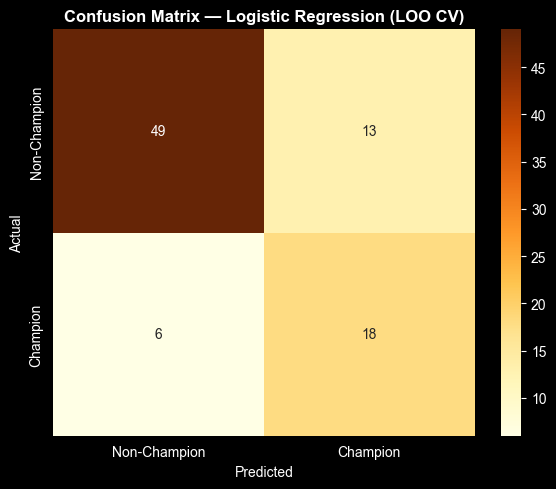

              precision    recall  f1-score   support

Non-Champion       0.89      0.79      0.84        62
    Champion       0.58      0.75      0.65        24

    accuracy                           0.78        86
   macro avg       0.74      0.77      0.75        86
weighted avg       0.80      0.78      0.79        86



In [25]:
# Pick the model with the best F1 from LOO
best_model_name = max(loo_results, key=lambda k: loo_results[k]['f1'])
best_model = models[best_model_name]
y_pred_best = cross_val_predict(best_model, X_scaled, y, cv=loo)

cm = confusion_matrix(y, y_pred_best)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=['Non-Champion', 'Champion'],
            yticklabels=['Non-Champion', 'Champion'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best_model_name} (LOO CV)', fontweight='bold')
plt.tight_layout()
plt.show()

print(classification_report(y, y_pred_best, target_names=['Non-Champion', 'Champion']))

### 4.8 Feature Importance Visualization

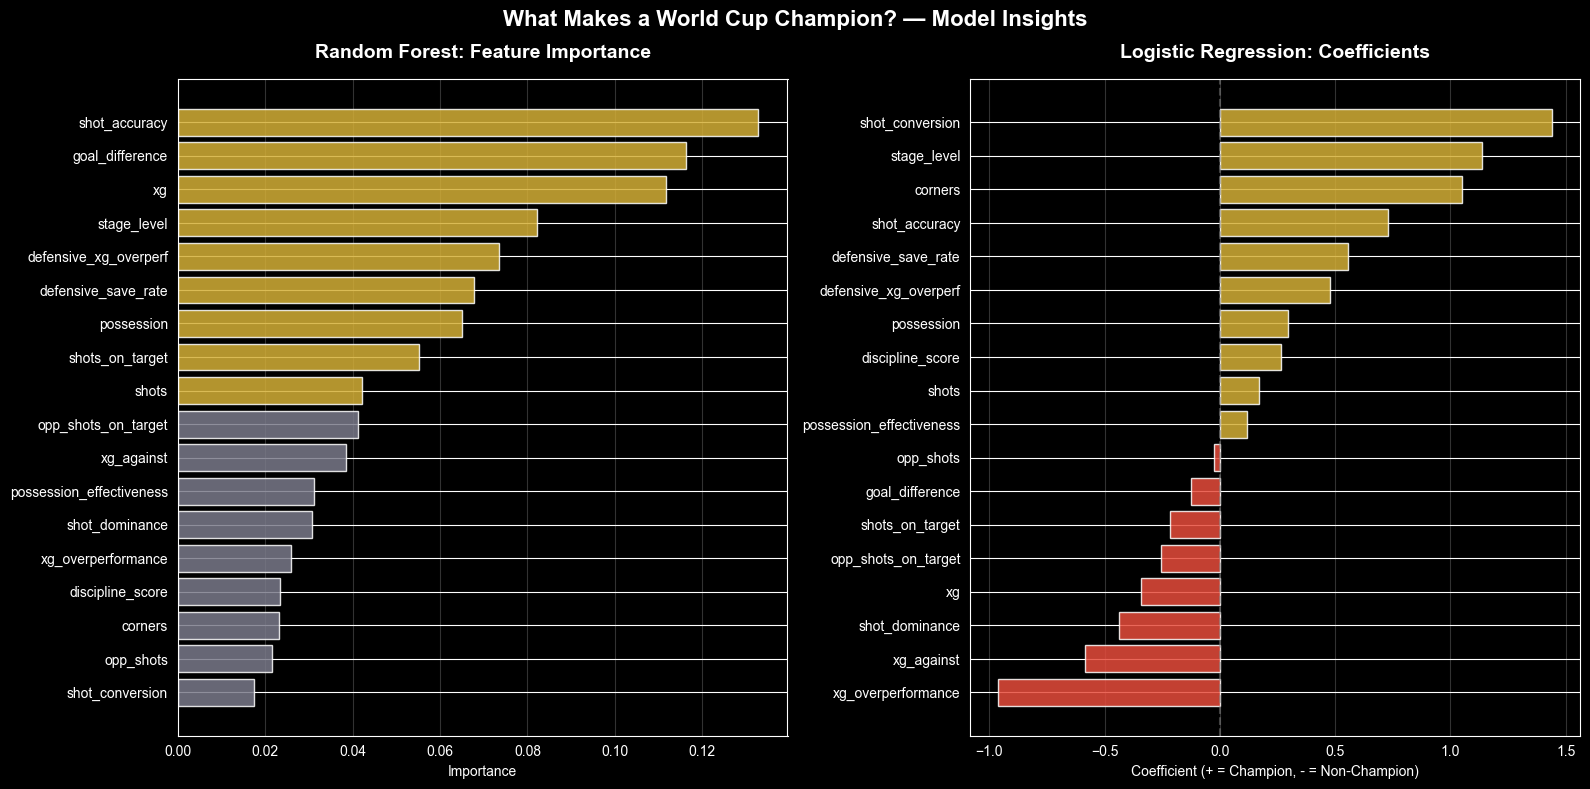

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Random Forest importance
imp_sorted = importances.sort_values('importance', ascending=True)
colors = ['#D4AF37' if v > imp_sorted['importance'].median() else '#7A7A8A' for v in imp_sorted['importance']]
ax1.barh(imp_sorted['feature'], imp_sorted['importance'], color=colors, alpha=0.85)
ax1.set_title('Random Forest: Feature Importance', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Importance')
ax1.grid(axis='x', alpha=0.2)

# Logistic Regression coefficients
coef_sorted = coefs.sort_values('coefficient', ascending=True)
colors2 = ['#D4AF37' if v > 0 else '#E74C3C' for v in coef_sorted['coefficient']]
ax2.barh(coef_sorted['feature'], coef_sorted['coefficient'], color=colors2, alpha=0.85)
ax2.axvline(x=0, color='gray', alpha=0.5, linestyle='--')
ax2.set_title('Logistic Regression: Coefficients', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Coefficient (+ = Champion, - = Non-Champion)')
ax2.grid(axis='x', alpha=0.2)

fig.suptitle('What Makes a World Cup Champion? — Model Insights', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.9 Model Comparison

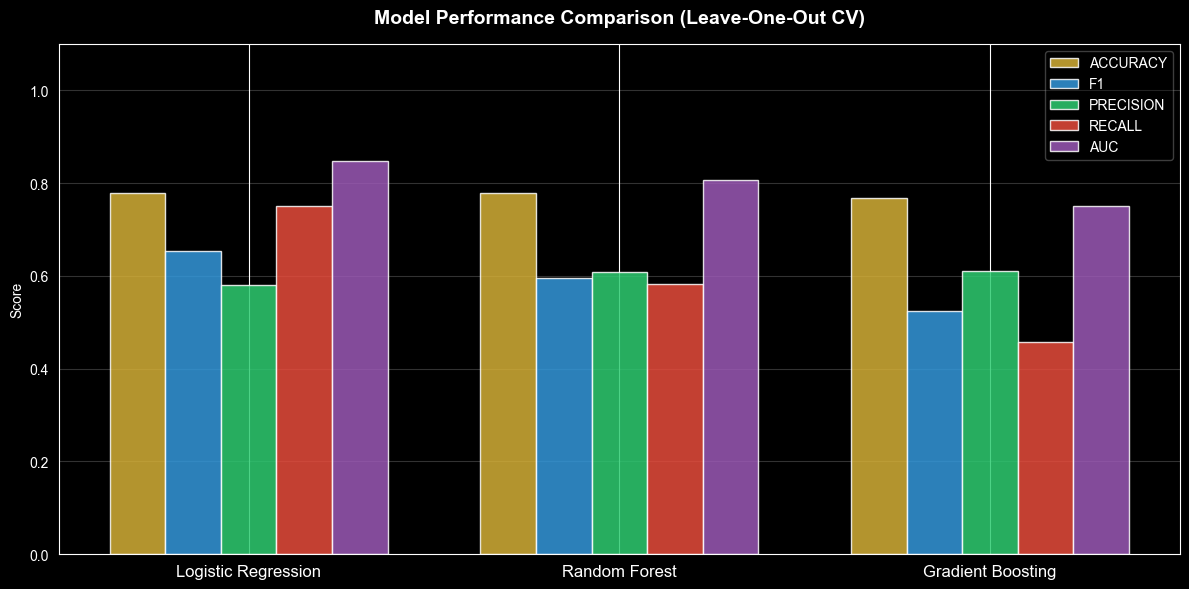

In [27]:
fig, ax = plt.subplots(figsize=(12, 6))

model_names = list(loo_results.keys())
metrics = ['accuracy', 'f1', 'precision', 'recall', 'auc']
x = np.arange(len(model_names))
width = 0.15
colors_met = ['#D4AF37', '#3498DB', '#2ECC71', '#E74C3C', '#9B59B6']

for i, metric in enumerate(metrics):
    vals = [loo_results[m][metric] for m in model_names]
    ax.bar(x + i * width, vals, width, label=metric.upper(), color=colors_met[i], alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(model_names, fontsize=12)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Model Performance Comparison (Leave-One-Out CV)', fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper right', framealpha=0.3)
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

## 5. Insights & Conclusions

### Results

| Model | Accuracy | F1 Score | ROC-AUC |
| --- | --- | --- | --- |
| **Logistic Regression** | **0.779** | **0.655** | **0.847** |
| Random Forest | 0.779 | 0.596 | 0.806 |
| Gradient Boosting | 0.767 | 0.524 | 0.750 |

### The 4 Traits of a World Cup Champion

1. **Clinical Finishing** — Champions convert 15.1% of shots vs 9.7%. They don't just shoot more, they score more efficiently.

2. **Defensive Solidity** — 93.5% save rate vs 87.0%. Champions concede 0.79 goals per match vs 1.92. They are extremely hard to score against.

3. **The Clutch Factor** — xG overperformance of +0.19 vs -0.13. Champions score more than the stats say they should — composure, star quality, or both.

4. **Match Dominance** — Goal difference of +1.5 vs -0.6, shot dominance ratio of 1.75x. Champions control matches, not just survive them.

### What Doesn't Matter
- **Discipline** — Champions average 2.67 vs 2.85. Virtually identical. Being "cleaner" doesn't make you a champion.

### Top Predictive Features (Random Forest)
1. Shot Accuracy
2. Goal Difference
3. Expected Goals (xG)
4. Stage Level (knockout rounds)
5. Defensive xG Overperformance

### Limitations
- Small dataset: 43 curated matches, not every World Cup game
- Some champions have only 1 match in the dataset
- xG data for older tournaments (1974–1990) may be estimated
- Results reflect correlation, not necessarily causation

### For the 2026 World Cup
Teams matching this champion profile should: convert 15%+ of shots, maintain 93%+ defensive save rate, overperform their xG, hold 53%+ possession, and outshoot opponents by 1.7x.